In [17]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import ttest_ind
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, make_scorer, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss, davies_bouldin_score
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, normalize
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, _tree
from xgboost import XGBClassifier


Text(0.5, 1.0, 'Weekly samples & defect ratio')

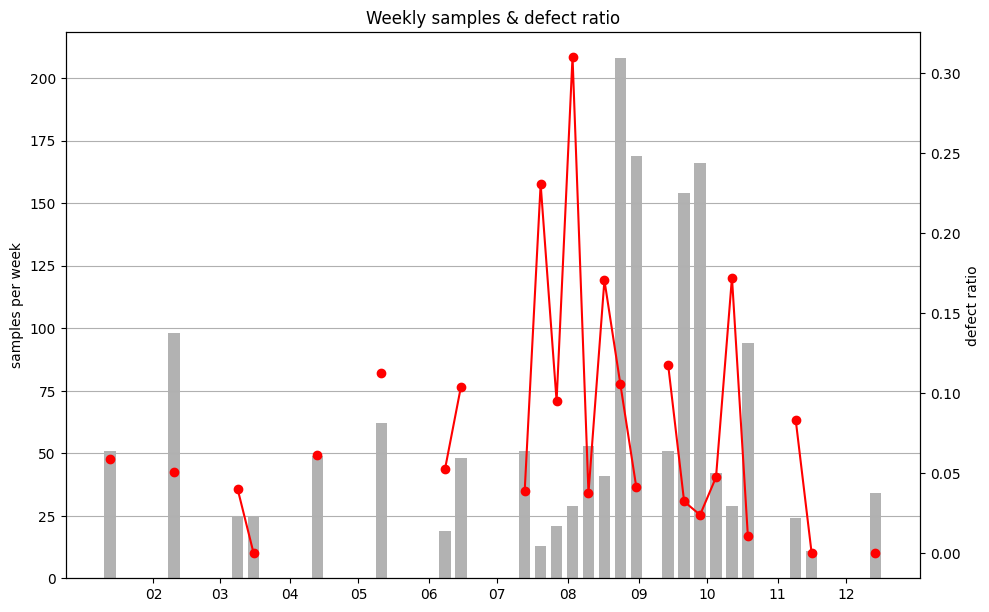

In [18]:
secom = pd.read_csv(data_path, sep='\t')
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

time_dt = pd.to_datetime(secom['Time'])
df = pd.DataFrame({'Time':time_dt, 'y':y}).sort_values('Time').set_index('Time')

w = df['y'].resample('W') # W means the end of the date
cnt, rate = w.size(), w.mean() # rate means 1/0 (fail/pass) less is better

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(cnt.index, cnt.values, width=5, alpha=0.3, color='k')
ax1.set_ylabel('samples per week')
ax1.grid(True, axis='y')

ax2 = ax1.twinx()
ax2.plot(rate.index, rate.values, marker='o', color='r')
ax2.set_ylabel('defect ratio')
months = pd.date_range(rate.index.min().normalize(),
                       rate.index.max().normalize(), freq='MS') 
ax2.set_xticks(months)
ax2.set_xticklabels([d.strftime('%m') for d in months], rotation=0, ha='center')

plt.tight_layout()
plt.title('Weekly samples & defect ratio')


PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


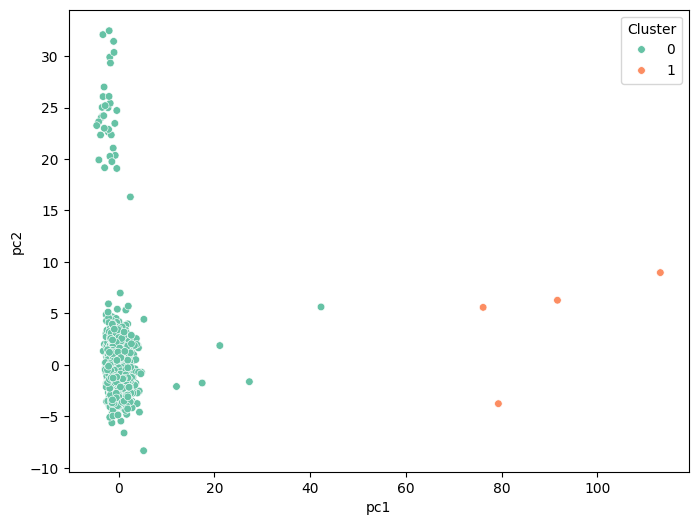

In [19]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個
PCA 保留 126 個主成分
cluster sizes: {0: 1156, 1: 1704}
cluster    0     1
y                 
0        747   683
1        409  1021


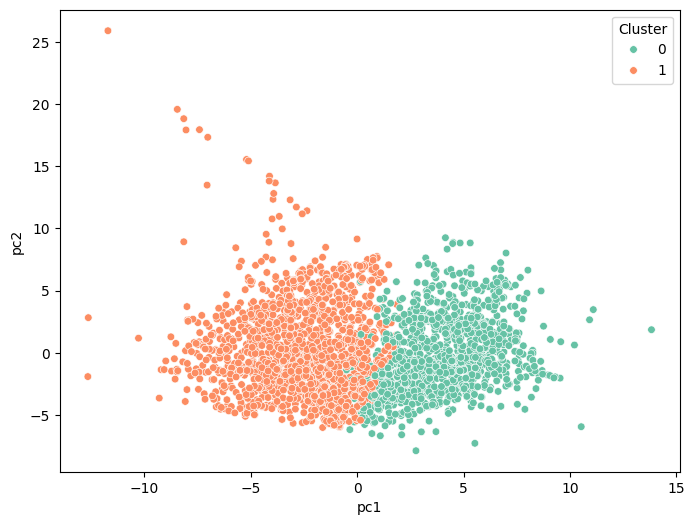

In [20]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()


In [25]:
mask = (labels == 0)
X_sub = X_smote.loc[mask].values
y_sub = y_smote.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=10)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        clf.fit(Xtr_res, ytr_res)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.957, FAR=0.067, ROCAU=0.967
Fold 2: acc=0.939, FAR=0.093, ROCAU=0.953
Fold 3: acc=0.939, FAR=0.094, ROCAU=0.953
Fold 4: acc=0.939, FAR=0.087, ROCAU=0.950
Fold 5: acc=0.931, FAR=0.107, ROCAU=0.946

=== SVM(RBF) ===
Fold 1: acc=1.000, FAR=0.000, ROCAU=1.000
Fold 2: acc=0.996, FAR=0.000, ROCAU=0.994
Fold 3: acc=0.996, FAR=0.000, ROCAU=0.994
Fold 4: acc=1.000, FAR=0.000, ROCAU=1.000
Fold 5: acc=1.000, FAR=0.000, ROCAU=1.000

=== DecisionTree ===
Fold 1: acc=0.892, FAR=0.133, ROCAU=0.903
Fold 2: acc=0.900, FAR=0.093, ROCAU=0.898
Fold 3: acc=0.896, FAR=0.128, ROCAU=0.906
Fold 4: acc=0.939, FAR=0.054, ROCAU=0.937
Fold 5: acc=0.935, FAR=0.074, ROCAU=0.939

=== RandomForest ===
Fold 1: acc=0.991, FAR=0.000, ROCAU=0.988
Fold 2: acc=0.974, FAR=0.000, ROCAU=0.963
Fold 3: acc=0.987, FAR=0.000, ROCAU=0.982
Fold 4: acc=0.991, FAR=0.000, ROCAU=0.988
Fold 5: acc=0.983, FAR=0.000, ROCAU=0.976

=== XGBoost ===
Fold 1: acc=0.996, FAR=0.007, ROCAU=0.997
Fold 2: acc

In [26]:
mask = (labels == 1)
X_sub = X_smote.loc[mask].values
y_sub = y_smote.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=10)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        clf.fit(Xtr_res, ytr_res)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.941, FAR=0.146, ROCAU=0.927
Fold 2: acc=0.941, FAR=0.146, ROCAU=0.927
Fold 3: acc=0.944, FAR=0.139, ROCAU=0.931
Fold 4: acc=0.935, FAR=0.147, ROCAU=0.922
Fold 5: acc=0.959, FAR=0.096, ROCAU=0.950

=== SVM(RBF) ===
Fold 1: acc=0.997, FAR=0.007, ROCAU=0.996
Fold 2: acc=1.000, FAR=0.000, ROCAU=1.000
Fold 3: acc=1.000, FAR=0.000, ROCAU=1.000
Fold 4: acc=1.000, FAR=0.000, ROCAU=1.000
Fold 5: acc=1.000, FAR=0.000, ROCAU=1.000

=== DecisionTree ===
Fold 1: acc=0.880, FAR=0.190, ROCAU=0.868
Fold 2: acc=0.921, FAR=0.095, ROCAU=0.918
Fold 3: acc=0.874, FAR=0.197, ROCAU=0.862
Fold 4: acc=0.897, FAR=0.162, ROCAU=0.887
Fold 5: acc=0.888, FAR=0.206, ROCAU=0.873

=== RandomForest ===
Fold 1: acc=0.997, FAR=0.000, ROCAU=0.998
Fold 2: acc=0.994, FAR=0.000, ROCAU=0.995
Fold 3: acc=0.985, FAR=0.015, ROCAU=0.985
Fold 4: acc=1.000, FAR=0.000, ROCAU=1.000
Fold 5: acc=1.000, FAR=0.000, ROCAU=1.000

=== XGBoost ===
Fold 1: acc=0.982, FAR=0.044, ROCAU=0.978
Fold 2: acc

---
---

In [43]:
mask = (labels == 0)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=10)
Xtr, ytr = smote.fit_resample(Xtr, ytr)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))


LogisticRegression confusion matrix:
[[114  18]
 [  6   6]]

SVM(RBF) confusion matrix:
[[131   1]
 [ 12   0]]

DecisionTree confusion matrix:
[[113  19]
 [ 10   2]]

RandomForest confusion matrix:
[[132   0]
 [ 11   1]]

XGBoost confusion matrix:
[[128   4]
 [ 10   2]]

Summary metrics:
                        acc     FAR  sensitivity  specificity      GM
model                                                               
LogisticRegression  0.8333  0.1364       0.5000       0.8636  0.6571
SVM(RBF)            0.9097  0.0076       0.0000       0.9924  0.0000
DecisionTree        0.7986  0.1439       0.1667       0.8561  0.3777
RandomForest        0.9236  0.0000       0.0833       1.0000  0.2887
XGBoost             0.9028  0.0303       0.1667       0.9697  0.4020


PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 共42個
PCA 保留 137 個主成分
cluster sizes: {0: 641, 1: 346, 2: 538}
cluster    0    1    2
y                     
0        592  327  511
1         49   19   27


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


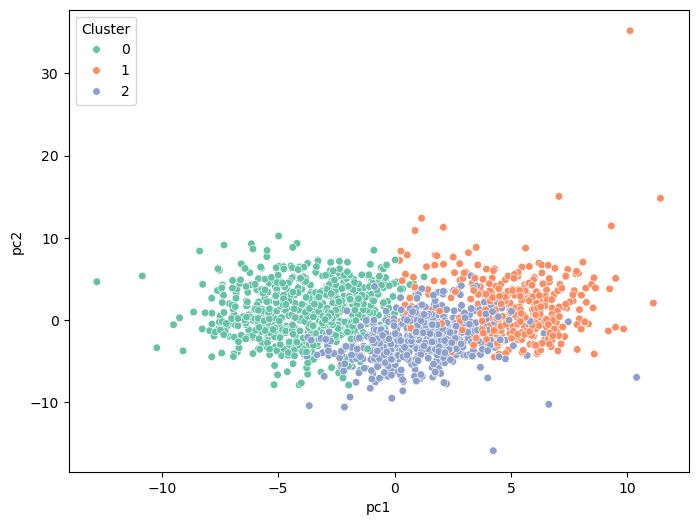

In [112]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, 共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=3, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

In [113]:
mask = (labels == 0)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=10)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        clf.fit(Xtr_res, ytr_res)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.853, FAR=0.076, ROCAU=0.462
Fold 2: acc=0.836, FAR=0.109, ROCAU=0.501
Fold 3: acc=0.812, FAR=0.127, ROCAU=0.486
Fold 4: acc=0.805, FAR=0.136, ROCAU=0.482
Fold 5: acc=0.828, FAR=0.127, ROCAU=0.586

=== SVM(RBF) ===
Fold 1: acc=0.922, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.938, FAR=0.000, ROCAU=0.556
Fold 3: acc=0.922, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.922, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.922, FAR=0.000, ROCAU=0.500

=== DecisionTree ===
Fold 1: acc=0.853, FAR=0.101, ROCAU=0.600
Fold 2: acc=0.852, FAR=0.109, ROCAU=0.612
Fold 3: acc=0.789, FAR=0.153, ROCAU=0.474
Fold 4: acc=0.844, FAR=0.102, ROCAU=0.549
Fold 5: acc=0.820, FAR=0.136, ROCAU=0.582

=== RandomForest ===
Fold 1: acc=0.922, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.922, FAR=0.008, ROCAU=0.496
Fold 3: acc=0.922, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.922, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.922, FAR=0.000, ROCAU=0.500

=== XGBoost ===
Fold 1: acc=0.907, FAR=0.025, ROCAU=0.537
Fold 2: acc

In [114]:
mask = (labels == 1)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=10)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        clf.fit(Xtr_res, ytr_res)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.929, FAR=0.030, ROCAU=0.610
Fold 2: acc=0.884, FAR=0.091, ROCAU=0.621
Fold 3: acc=0.884, FAR=0.062, ROCAU=0.469
Fold 4: acc=0.899, FAR=0.046, ROCAU=0.477
Fold 5: acc=0.870, FAR=0.077, ROCAU=0.462

=== SVM(RBF) ===
Fold 1: acc=0.943, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.957, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.942, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.942, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.928, FAR=0.015, ROCAU=0.492

=== DecisionTree ===
Fold 1: acc=0.814, FAR=0.136, ROCAU=0.432
Fold 2: acc=0.928, FAR=0.030, ROCAU=0.485
Fold 3: acc=0.870, FAR=0.077, ROCAU=0.462
Fold 4: acc=0.870, FAR=0.108, ROCAU=0.696
Fold 5: acc=0.870, FAR=0.077, ROCAU=0.462

=== RandomForest ===
Fold 1: acc=0.943, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.957, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.942, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.942, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.942, FAR=0.000, ROCAU=0.500

=== XGBoost ===
Fold 1: acc=0.943, FAR=0.000, ROCAU=0.500
Fold 2: acc

In [115]:
mask = (labels == 2)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=10)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        clf.fit(Xtr_res, ytr_res)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.935, FAR=0.029, ROCAU=0.585
Fold 2: acc=0.917, FAR=0.059, ROCAU=0.721
Fold 3: acc=0.870, FAR=0.088, ROCAU=0.539
Fold 4: acc=0.953, FAR=0.020, ROCAU=0.690
Fold 5: acc=0.916, FAR=0.039, ROCAU=0.480

=== SVM(RBF) ===
Fold 1: acc=0.954, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.944, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.944, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.953, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.953, FAR=0.000, ROCAU=0.500

=== DecisionTree ===
Fold 1: acc=0.917, FAR=0.039, ROCAU=0.481
Fold 2: acc=0.898, FAR=0.059, ROCAU=0.554
Fold 3: acc=0.787, FAR=0.186, ROCAU=0.574
Fold 4: acc=0.944, FAR=0.039, ROCAU=0.780
Fold 5: acc=0.925, FAR=0.029, ROCAU=0.485

=== RandomForest ===
Fold 1: acc=0.954, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.944, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.944, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.953, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.953, FAR=0.000, ROCAU=0.500

=== XGBoost ===
Fold 1: acc=0.954, FAR=0.000, ROCAU=0.500
Fold 2: acc

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 共42個
PCA 保留 137 個主成分
cluster sizes: {0: 552, 1: 243, 2: 555, 3: 175}
cluster    0    1    2    3
y                          
0        513  231  523  163
1         39   12   32   12


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


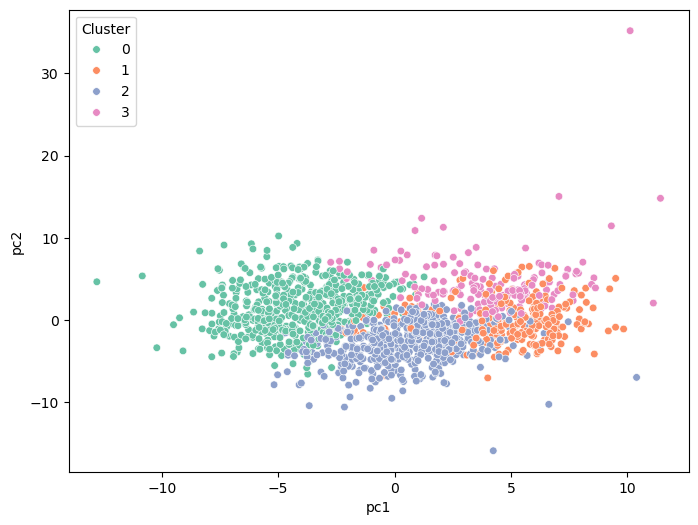

In [99]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, 共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=4, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

In [100]:
mask = (labels == 0)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=3)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        clf.fit(Xtr_res, ytr_res)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.874, FAR=0.058, ROCAU=0.471
Fold 2: acc=0.856, FAR=0.087, ROCAU=0.519
Fold 3: acc=0.891, FAR=0.078, ROCAU=0.675
Fold 4: acc=0.845, FAR=0.098, ROCAU=0.513
Fold 5: acc=0.800, FAR=0.147, ROCAU=0.489

=== SVM(RBF) ===
Fold 1: acc=0.928, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.928, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.936, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.927, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.927, FAR=0.000, ROCAU=0.500

=== DecisionTree ===
Fold 1: acc=0.865, FAR=0.078, ROCAU=0.524
Fold 2: acc=0.793, FAR=0.146, ROCAU=0.427
Fold 3: acc=0.791, FAR=0.155, ROCAU=0.422
Fold 4: acc=0.791, FAR=0.157, ROCAU=0.484
Fold 5: acc=0.873, FAR=0.078, ROCAU=0.586

=== RandomForest ===
Fold 1: acc=0.928, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.928, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.936, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.927, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.927, FAR=0.000, ROCAU=0.500

=== XGBoost ===
Fold 1: acc=0.928, FAR=0.000, ROCAU=0.500
Fold 2: acc

In [101]:
mask = (labels == 1)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=3)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        clf.fit(Xtr_res, ytr_res)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.857, FAR=0.109, ROCAU=0.612
Fold 2: acc=0.939, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.918, FAR=0.043, ROCAU=0.479
Fold 4: acc=0.917, FAR=0.043, ROCAU=0.478
Fold 5: acc=0.917, FAR=0.043, ROCAU=0.478

=== SVM(RBF) ===
Fold 1: acc=0.939, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.939, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.959, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.958, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.958, FAR=0.000, ROCAU=0.500

=== DecisionTree ===
Fold 1: acc=0.857, FAR=0.087, ROCAU=0.457
Fold 2: acc=0.878, FAR=0.087, ROCAU=0.623
Fold 3: acc=0.878, FAR=0.106, ROCAU=0.697
Fold 4: acc=0.917, FAR=0.043, ROCAU=0.478
Fold 5: acc=0.896, FAR=0.087, ROCAU=0.707

=== RandomForest ===
Fold 1: acc=0.939, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.939, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.959, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.958, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.958, FAR=0.000, ROCAU=0.500

=== XGBoost ===
Fold 1: acc=0.918, FAR=0.022, ROCAU=0.489
Fold 2: acc

In [102]:
mask = (labels == 2)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=3)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        clf.fit(Xtr_res, ytr_res)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.865, FAR=0.095, ROCAU=0.536
Fold 2: acc=0.928, FAR=0.029, ROCAU=0.569
Fold 3: acc=0.901, FAR=0.076, ROCAU=0.712
Fold 4: acc=0.892, FAR=0.058, ROCAU=0.543
Fold 5: acc=0.901, FAR=0.058, ROCAU=0.614

=== SVM(RBF) ===
Fold 1: acc=0.946, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.946, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.946, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.937, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.937, FAR=0.000, ROCAU=0.500

=== DecisionTree ===
Fold 1: acc=0.838, FAR=0.124, ROCAU=0.521
Fold 2: acc=0.820, FAR=0.133, ROCAU=0.433
Fold 3: acc=0.802, FAR=0.152, ROCAU=0.424
Fold 4: acc=0.883, FAR=0.067, ROCAU=0.538
Fold 5: acc=0.892, FAR=0.058, ROCAU=0.543

=== RandomForest ===
Fold 1: acc=0.946, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.946, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.946, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.937, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.937, FAR=0.000, ROCAU=0.500

=== XGBoost ===
Fold 1: acc=0.946, FAR=0.000, ROCAU=0.500
Fold 2: acc

In [103]:
mask = (labels == 3)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=3)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        clf.fit(Xtr_res, ytr_res)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.971, FAR=0.030, ROCAU=0.985
Fold 2: acc=0.857, FAR=0.091, ROCAU=0.455
Fold 3: acc=0.943, FAR=0.030, ROCAU=0.735
Fold 4: acc=0.800, FAR=0.188, ROCAU=0.740
Fold 5: acc=0.857, FAR=0.062, ROCAU=0.469

=== SVM(RBF) ===
Fold 1: acc=0.943, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.943, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.943, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.914, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.914, FAR=0.000, ROCAU=0.500

=== DecisionTree ===
Fold 1: acc=0.943, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.857, FAR=0.091, ROCAU=0.455
Fold 3: acc=0.800, FAR=0.152, ROCAU=0.424
Fold 4: acc=0.857, FAR=0.062, ROCAU=0.469
Fold 5: acc=0.800, FAR=0.125, ROCAU=0.438

=== RandomForest ===
Fold 1: acc=0.943, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.943, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.943, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.914, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.914, FAR=0.000, ROCAU=0.500

=== XGBoost ===
Fold 1: acc=0.943, FAR=0.000, ROCAU=0.500
Fold 2: acc

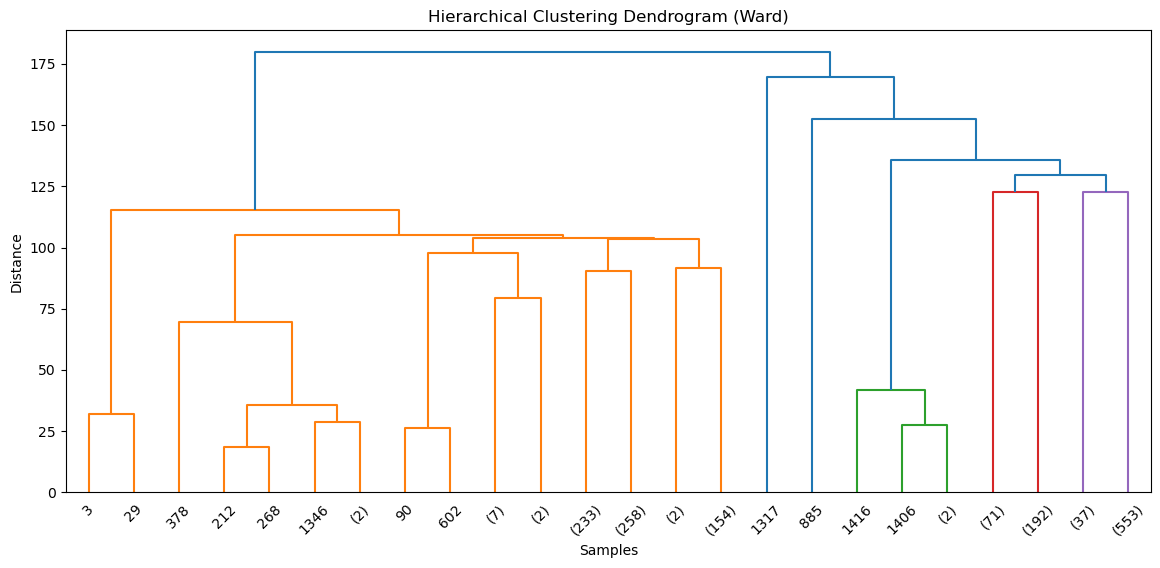

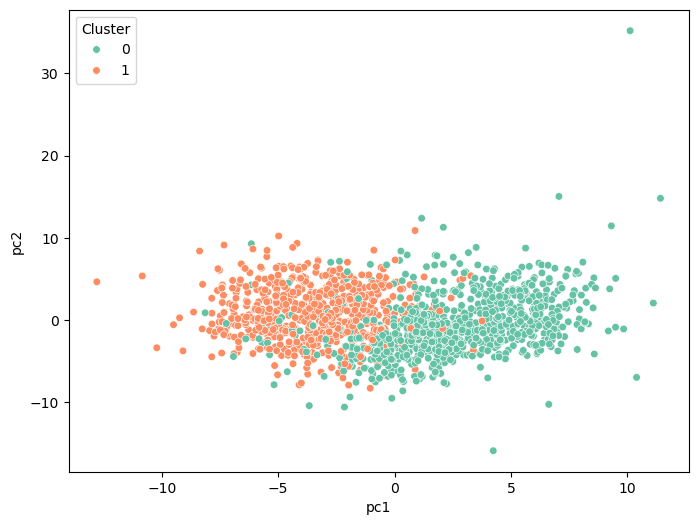

cluster    0    1
y                
0        822  608
1         37   58


In [132]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

# 用 Ward linkage 建 dendrogram（agglomerative 標準做法）
Z = linkage(X_pca, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='level', p=5)   # p=5 保留前幾層以免太大
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = agg.fit_predict(X_pca)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

In [ ]:
mask = (labels == 0)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=10)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        clf.fit(Xtr_res, ytr_res)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.866, FAR=0.109, ROCAU=0.588
Fold 2: acc=0.878, FAR=0.085, ROCAU=0.458
Fold 3: acc=0.924, FAR=0.037, ROCAU=0.544
Fold 4: acc=0.890, FAR=0.085, ROCAU=0.645
Fold 5: acc=0.895, FAR=0.067, ROCAU=0.466

=== SVM(RBF) ===
Fold 1: acc=0.959, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.959, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.953, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.953, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.959, FAR=0.000, ROCAU=0.500

=== DecisionTree ===
Fold 1: acc=0.901, FAR=0.079, ROCAU=0.675
Fold 2: acc=0.890, FAR=0.079, ROCAU=0.532
Fold 3: acc=0.919, FAR=0.043, ROCAU=0.541
Fold 4: acc=0.895, FAR=0.073, ROCAU=0.588
Fold 5: acc=0.854, FAR=0.110, ROCAU=0.445

=== RandomForest ===
Fold 1: acc=0.959, FAR=0.000, ROCAU=0.500
Fold 2: acc=0.959, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.953, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.959, FAR=0.000, ROCAU=0.562
Fold 5: acc=0.959, FAR=0.000, ROCAU=0.500

=== XGBoost ===
Fold 1: acc=0.965, FAR=0.000, ROCAU=0.571
Fold 2: acc

In [ ]:
mask = (labels == 1)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=10)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        clf.fit(Xtr_res, ytr_res)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.784, FAR=0.172, ROCAU=0.581
Fold 2: acc=0.865, FAR=0.082, ROCAU=0.595
Fold 3: acc=0.820, FAR=0.123, ROCAU=0.529
Fold 4: acc=0.820, FAR=0.124, ROCAU=0.563
Fold 5: acc=0.842, FAR=0.099, ROCAU=0.575

=== SVM(RBF) ===
Fold 1: acc=0.910, FAR=0.008, ROCAU=0.538
Fold 2: acc=0.917, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.917, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.910, FAR=0.000, ROCAU=0.500
Fold 5: acc=0.910, FAR=0.000, ROCAU=0.500

=== DecisionTree ===
Fold 1: acc=0.821, FAR=0.098, ROCAU=0.451
Fold 2: acc=0.805, FAR=0.131, ROCAU=0.480
Fold 3: acc=0.865, FAR=0.082, ROCAU=0.595
Fold 4: acc=0.782, FAR=0.157, ROCAU=0.505
Fold 5: acc=0.752, FAR=0.223, ROCAU=0.638

=== RandomForest ===
Fold 1: acc=0.903, FAR=0.008, ROCAU=0.496
Fold 2: acc=0.917, FAR=0.000, ROCAU=0.500
Fold 3: acc=0.917, FAR=0.000, ROCAU=0.500
Fold 4: acc=0.902, FAR=0.008, ROCAU=0.496
Fold 5: acc=0.910, FAR=0.000, ROCAU=0.500

=== XGBoost ===
Fold 1: acc=0.888, FAR=0.033, ROCAU=0.525
Fold 2: acc

In [141]:
outlier_idx = [8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61,
               72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196,
               275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489]

# secom: 原始 UCI 資料（含 label）
# X_proc: 你用來做 PCA / 建模的特徵矩陣（KNN 填補、篩選後的那一版）
# y: 對應 label（0/1）

secom_out = secom.iloc[outlier_idx].copy()
X_out = X_imp.iloc[outlier_idx].copy()
y_out = y.iloc[outlier_idx].copy()

print("全體類別比例：")
print(y.value_counts(normalize=True))

print("\noutlier 類別比例：")
print(y_out.value_counts(normalize=True))



全體類別比例：
Pass/Fail
0    0.937705
1    0.062295
Name: proportion, dtype: float64

outlier 類別比例：
Pass/Fail
0    0.928571
1    0.071429
Name: proportion, dtype: float64


In [148]:
y_out.value_counts()

Pass/Fail
0    39
1     3
Name: count, dtype: int64